In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\15_min\df_BU_TotActPwr_Academy.parquet"
df_imputed = pd.read_parquet(path)

In [7]:
# ============================================================
# USER SETTINGS
# ============================================================
path_output = r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260410_143121_3cf17790_xgboost_BU_TotActPwr_Academy_profile_predictions.csv"
PREDICTION_CSV_PATH = Path(path_output)

TARGET_COL = "BU_TotActPwr_Academy"

TEST_START_DAY = "2026-02-01"
TEST_END_DAY   = "2026-02-07"

HORIZON_STEPS = 96
FREQ_MINUTES = 15

UPDATE_HOURS = [6, 12, 18]

# Safe first setting
CLIP_LOW = 0.80
CLIP_HIGH = 1.20

# If denominator is too small, no correction is applied
EPS = 1e-6

In [8]:
def mape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def smape_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (denominator != 0)

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def evaluate_vector(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)

    if mask.sum() == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "MAPE": np.nan,
            "sMAPE": np.nan,
            "R2": np.nan,
        }

    yt = y_true[mask]
    yp = y_pred[mask]

    rmse = np.sqrt(mean_squared_error(yt, yp))

    return {
        "MAE": mean_absolute_error(yt, yp),
        "RMSE": rmse,
        "MAPE": mape_safe(yt, yp),
        "sMAPE": smape_safe(yt, yp),
        "R2": r2_score(yt, yp) if len(yt) > 1 else np.nan,
    }


def daily_energy_kwh(profile_kw, freq_minutes=15):
    profile_kw = np.asarray(profile_kw, dtype=float)
    return np.nansum(profile_kw) * (freq_minutes / 60)


def peak_kw(profile_kw):
    profile_kw = np.asarray(profile_kw, dtype=float)
    if np.all(~np.isfinite(profile_kw)):
        return np.nan
    return np.nanmax(profile_kw)

In [9]:
def load_profile_prediction_csv(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Prediction CSV not found: {path}")

    df_pred = pd.read_csv(path)

    # The profile prediction file is usually saved with the issue time as index.
    # Depending on pandas saving/loading, the first column may be unnamed.
    first_col = df_pred.columns[0]

    if first_col.lower() in ["time", "date", "datetime"]:
        df_pred[first_col] = pd.to_datetime(df_pred[first_col], errors="coerce")
        df_pred = df_pred.dropna(subset=[first_col]).set_index(first_col)
    elif first_col.startswith("Unnamed"):
        df_pred[first_col] = pd.to_datetime(df_pred[first_col], errors="coerce")
        df_pred = df_pred.dropna(subset=[first_col]).set_index(first_col)
    else:
        # Try using first column as datetime index
        parsed = pd.to_datetime(df_pred[first_col], errors="coerce")
        if parsed.notna().mean() > 0.8:
            df_pred[first_col] = parsed
            df_pred = df_pred.dropna(subset=[first_col]).set_index(first_col)
        else:
            raise ValueError(
                "Could not identify datetime index column in prediction CSV. "
                "Please check the first columns using pd.read_csv(path).head()."
            )

    df_pred = df_pred.sort_index()

    true_cols = [f"y_tplus_{i:03d}_true" for i in range(1, HORIZON_STEPS + 1)]
    pred_cols = [f"y_tplus_{i:03d}_pred" for i in range(1, HORIZON_STEPS + 1)]

    missing_true = [c for c in true_cols if c not in df_pred.columns]
    missing_pred = [c for c in pred_cols if c not in df_pred.columns]

    if missing_true or missing_pred:
        raise ValueError(
            "Prediction CSV does not have expected wide profile columns.\n"
            f"Missing true cols example: {missing_true[:5]}\n"
            f"Missing pred cols example: {missing_pred[:5]}"
        )

    return df_pred, true_cols, pred_cols


df_pred, true_cols, pred_cols = load_profile_prediction_csv(PREDICTION_CSV_PATH)

print("Loaded prediction file:")
print(df_pred.shape)
print(df_pred.index.min(), "to", df_pred.index.max())
df_pred.head()

Loaded prediction file:
(17, 192)
2026-01-21 23:45:00 to 2026-02-07 23:45:00


,y_tplus_001_true,y_tplus_002_true,y_tplus_003_true,y_tplus_004_true,y_tplus_005_true,y_tplus_006_true,y_tplus_007_true,y_tplus_008_true,y_tplus_009_true,y_tplus_010_true,...,y_tplus_087_pred,y_tplus_088_pred,y_tplus_089_pred,y_tplus_090_pred,y_tplus_091_pred,y_tplus_092_pred,y_tplus_093_pred,y_tplus_094_pred,y_tplus_095_pred,y_tplus_096_pred
Time,,,,,,,,,,,,,,,,,,,,,
2026-01-21 23:45:00,3.98733,5.02400,4.01300,4.35833,3.99167,2.73800,3.64333,3.24700,2.67233,4.16433,...,4.723116,4.718125,4.672813,4.374898,4.603741,4.677884,3.895474,4.071367,4.516047,4.375801
2026-01-22 23:45:00,5.48000,3.91333,4.51933,5.26467,3.67800,2.97933,4.12300,3.02733,3.57767,3.20400,...,4.226722,4.674653,4.623615,4.299330,4.515628,4.503637,3.958176,3.992547,3.819713,4.221804
2026-01-23 23:45:00,5.26633,4.21667,5.09333,4.76533,3.86400,4.39067,3.10867,3.50200,3.71433,2.67233,...,4.581752,4.345755,4.717009,4.193090,4.505078,4.521610,4.020883,4.086853,3.861026,4.213466
2026-01-24 23:45:00,3.88733,4.53933,4.88000,3.97000,3.84567,4.14500,3.01800,3.74767,3.42233,2.98167,...,4.501969,4.451086,4.601683,4.394070,4.323882,4.639409,4.016401,4.158621,3.841243,3.968292
2026-01-25 23:45:00,3.86700,4.40600,5.02100,4.08033,4.59267,3.38700,3.22867,3.75600,2.72300,2.74233,...,4.388243,4.864736,4.948907,5.012081,4.973212,4.666981,4.355872,4.711518,4.698251,5.248673


In [10]:
def add_forecast_day(df):
    out = df.copy()

    if not isinstance(out.index, pd.DatetimeIndex):
        raise TypeError("Prediction dataframe must have a DatetimeIndex.")

    out["issue_time"] = out.index
    out["forecast_day"] = (out.index + pd.Timedelta(days=1)).normalize()

    return out


df_eval = add_forecast_day(df_pred)

test_start = pd.to_datetime(TEST_START_DAY)
test_end = pd.to_datetime(TEST_END_DAY)

df_eval = df_eval[
    (df_eval["forecast_day"] >= test_start) &
    (df_eval["forecast_day"] <= test_end)
].copy()

if df_eval.empty:
    raise ValueError(
        "No rows found for selected test forecast days. "
        "Check TEST_START_DAY, TEST_END_DAY, and prediction CSV index."
    )

print("Selected test forecast days:")
print(df_eval[["issue_time", "forecast_day"]])
print("Number of forecast days:", len(df_eval))

Selected test forecast days:
                             issue_time forecast_day
Time                                                
2026-01-31 23:45:00 2026-01-31 23:45:00   2026-02-01
2026-02-01 23:45:00 2026-02-01 23:45:00   2026-02-02
2026-02-02 23:45:00 2026-02-02 23:45:00   2026-02-03
2026-02-03 23:45:00 2026-02-03 23:45:00   2026-02-04
2026-02-04 23:45:00 2026-02-04 23:45:00   2026-02-05
2026-02-05 23:45:00 2026-02-05 23:45:00   2026-02-06
2026-02-06 23:45:00 2026-02-06 23:45:00   2026-02-07
Number of forecast days: 7


In [11]:
def adaptive_scale_profile(
    y_true,
    y_pred,
    update_hour,
    *,
    freq_minutes=15,
    clip_low=0.80,
    clip_high=1.20,
    eps=1e-6,
):
    """
    Adaptive same-day scaling.

    y_true: actual full-day profile, length 96
    y_pred: original day-ahead predicted full-day profile, length 96

    At update_hour, actual values up to that time are known.
    The function corrects only the remaining forecast.
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if len(y_true) != len(y_pred):
        raise ValueError("y_true and y_pred must have same length.")

    steps_per_hour = int(60 / freq_minutes)

    # Include observed values up to update_hour:00
    # 06:00 corresponds to steps 00:00 ... 06:00 inclusive = 25 points
    observed_end_step = update_hour * steps_per_hour + 1

    observed_end_step = min(observed_end_step, len(y_true))

    adaptive_pred = y_pred.copy()

    actual_so_far = y_true[:observed_end_step]
    pred_so_far = y_pred[:observed_end_step]

    valid_mask = np.isfinite(actual_so_far) & np.isfinite(pred_so_far)

    if valid_mask.sum() == 0:
        correction_factor = 1.0
    else:
        actual_sum = np.nansum(actual_so_far[valid_mask])
        pred_sum = np.nansum(pred_so_far[valid_mask])

        if abs(pred_sum) < eps:
            correction_factor = 1.0
        else:
            correction_factor = actual_sum / pred_sum

    correction_factor_clipped = float(
        np.clip(correction_factor, clip_low, clip_high)
    )

    # Correct only future remaining part
    adaptive_pred[observed_end_step:] = (
        adaptive_pred[observed_end_step:] * correction_factor_clipped
    )

    # Optional: for full-day hybrid evaluation, observed past is actual
    full_day_hybrid = adaptive_pred.copy()
    full_day_hybrid[:observed_end_step] = y_true[:observed_end_step]

    return {
        "adaptive_remaining_pred": adaptive_pred,
        "full_day_hybrid_pred": full_day_hybrid,
        "observed_end_step": observed_end_step,
        "correction_factor_raw": float(correction_factor),
        "correction_factor_clipped": correction_factor_clipped,
    }

In [12]:
def evaluate_adaptive_experiment(df_eval, true_cols, pred_cols):
    rows = []
    daily_rows = []

    # ---------- Static forecast ----------
    y_true_all = df_eval[true_cols].to_numpy(dtype=float)
    y_pred_all = df_eval[pred_cols].to_numpy(dtype=float)

    static_metrics = evaluate_vector(y_true_all.ravel(), y_pred_all.ravel())

    rows.append({
        "method": "static_day_ahead",
        "update_hour": np.nan,
        "evaluation_scope": "full_day",
        **static_metrics,
    })

    for issue_time, row in df_eval.iterrows():
        y_true = row[true_cols].to_numpy(dtype=float)
        y_pred = row[pred_cols].to_numpy(dtype=float)

        forecast_day = row["forecast_day"]

        daily_rows.append({
            "forecast_day": forecast_day,
            "issue_time": issue_time,
            "method": "static_day_ahead",
            "update_hour": np.nan,
            "correction_factor_raw": np.nan,
            "correction_factor_clipped": np.nan,
            "actual_energy_kwh": daily_energy_kwh(y_true, FREQ_MINUTES),
            "pred_energy_kwh": daily_energy_kwh(y_pred, FREQ_MINUTES),
            "energy_abs_error_kwh": abs(
                daily_energy_kwh(y_true, FREQ_MINUTES)
                - daily_energy_kwh(y_pred, FREQ_MINUTES)
            ),
            "energy_pct_error": (
                abs(daily_energy_kwh(y_true, FREQ_MINUTES) - daily_energy_kwh(y_pred, FREQ_MINUTES))
                / daily_energy_kwh(y_true, FREQ_MINUTES) * 100
                if daily_energy_kwh(y_true, FREQ_MINUTES) != 0 else np.nan
            ),
            "actual_peak_kw": peak_kw(y_true),
            "pred_peak_kw": peak_kw(y_pred),
            "peak_abs_error_kw": abs(peak_kw(y_true) - peak_kw(y_pred)),
            "profile_MAPE": mape_safe(y_true, y_pred),
            "profile_sMAPE": smape_safe(y_true, y_pred),
            "profile_MAE": mean_absolute_error(y_true, y_pred),
            "profile_RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        })

    # ---------- Adaptive forecast ----------
    for update_hour in UPDATE_HOURS:
        remaining_true_all = []
        remaining_pred_all = []

        hybrid_true_all = []
        hybrid_pred_all = []

        for issue_time, row in df_eval.iterrows():
            y_true = row[true_cols].to_numpy(dtype=float)
            y_pred = row[pred_cols].to_numpy(dtype=float)

            result = adaptive_scale_profile(
                y_true,
                y_pred,
                update_hour=update_hour,
                freq_minutes=FREQ_MINUTES,
                clip_low=CLIP_LOW,
                clip_high=CLIP_HIGH,
                eps=EPS,
            )

            adaptive_pred = result["adaptive_remaining_pred"]
            full_day_hybrid = result["full_day_hybrid_pred"]
            observed_end_step = result["observed_end_step"]

            # Remaining horizon only
            remaining_true = y_true[observed_end_step:]
            remaining_pred = adaptive_pred[observed_end_step:]

            remaining_true_all.append(remaining_true)
            remaining_pred_all.append(remaining_pred)

            # Full-day hybrid
            hybrid_true_all.append(y_true)
            hybrid_pred_all.append(full_day_hybrid)

            forecast_day = row["forecast_day"]

            daily_rows.append({
                "forecast_day": forecast_day,
                "issue_time": issue_time,
                "method": f"adaptive_{update_hour:02d}h",
                "update_hour": update_hour,
                "correction_factor_raw": result["correction_factor_raw"],
                "correction_factor_clipped": result["correction_factor_clipped"],
                "actual_energy_kwh": daily_energy_kwh(y_true, FREQ_MINUTES),
                "pred_energy_kwh": daily_energy_kwh(full_day_hybrid, FREQ_MINUTES),
                "energy_abs_error_kwh": abs(
                    daily_energy_kwh(y_true, FREQ_MINUTES)
                    - daily_energy_kwh(full_day_hybrid, FREQ_MINUTES)
                ),
                "energy_pct_error": (
                    abs(daily_energy_kwh(y_true, FREQ_MINUTES) - daily_energy_kwh(full_day_hybrid, FREQ_MINUTES))
                    / daily_energy_kwh(y_true, FREQ_MINUTES) * 100
                    if daily_energy_kwh(y_true, FREQ_MINUTES) != 0 else np.nan
                ),
                "actual_peak_kw": peak_kw(y_true),
                "pred_peak_kw": peak_kw(full_day_hybrid),
                "peak_abs_error_kw": abs(peak_kw(y_true) - peak_kw(full_day_hybrid)),
                "profile_MAPE": mape_safe(y_true, full_day_hybrid),
                "profile_sMAPE": smape_safe(y_true, full_day_hybrid),
                "profile_MAE": mean_absolute_error(y_true, full_day_hybrid),
                "profile_RMSE": np.sqrt(mean_squared_error(y_true, full_day_hybrid)),
            })

        remaining_true_all = np.concatenate(remaining_true_all)
        remaining_pred_all = np.concatenate(remaining_pred_all)

        hybrid_true_all = np.vstack(hybrid_true_all)
        hybrid_pred_all = np.vstack(hybrid_pred_all)

        remaining_metrics = evaluate_vector(remaining_true_all, remaining_pred_all)
        hybrid_metrics = evaluate_vector(hybrid_true_all.ravel(), hybrid_pred_all.ravel())

        rows.append({
            "method": f"adaptive_{update_hour:02d}h",
            "update_hour": update_hour,
            "evaluation_scope": "remaining_horizon_only",
            **remaining_metrics,
        })

        rows.append({
            "method": f"adaptive_{update_hour:02d}h",
            "update_hour": update_hour,
            "evaluation_scope": "full_day_hybrid",
            **hybrid_metrics,
        })

    summary_df = pd.DataFrame(rows)
    daily_df = pd.DataFrame(daily_rows)

    return summary_df, daily_df


adaptive_summary, adaptive_daily = evaluate_adaptive_experiment(
    df_eval=df_eval,
    true_cols=true_cols,
    pred_cols=pred_cols,
)

adaptive_summary

,method,update_hour,evaluation_scope,MAE,RMSE,MAPE,sMAPE,R2
0,static_day_ahead,NaN,full_day,2.702757,4.595023,20.539877,22.198433,0.703019
1,adaptive_06h,6.0,remaining_horizon_only,3.325063,5.142223,23.764234,24.258552,0.654745
2,adaptive_06h,6.0,full_day_hybrid,2.459161,4.422262,17.575632,17.941221,0.724931
3,adaptive_12h,12.0,remaining_horizon_only,2.345246,3.542141,24.572695,22.417588,0.820054
4,adaptive_12h,12.0,full_day_hybrid,1.148193,2.478444,12.030382,10.975277,0.913601
5,adaptive_18h,18.0,remaining_horizon_only,0.926263,1.100024,23.791544,20.218477,-1.471318
6,adaptive_18h,18.0,full_day_hybrid,0.221917,0.538431,5.700057,4.844010,0.995922


In [13]:
adaptive_daily_summary = (
    adaptive_daily
    .groupby("method")
    .agg(
        mean_profile_MAPE=("profile_MAPE", "mean"),
        mean_profile_sMAPE=("profile_sMAPE", "mean"),
        mean_profile_MAE=("profile_MAE", "mean"),
        mean_profile_RMSE=("profile_RMSE", "mean"),
        mean_energy_abs_error_kwh=("energy_abs_error_kwh", "mean"),
        mean_energy_pct_error=("energy_pct_error", "mean"),
        mean_peak_abs_error_kw=("peak_abs_error_kw", "mean"),
        mean_correction_factor=("correction_factor_clipped", "mean"),
    )
    .reset_index()
)

adaptive_daily_summary

,method,mean_profile_MAPE,mean_profile_sMAPE,mean_profile_MAE,mean_profile_RMSE,mean_energy_abs_error_kwh,mean_energy_pct_error,mean_peak_abs_error_kw,mean_correction_factor
0,adaptive_06h,17.575632,17.941221,2.459161,4.014680,45.347921,16.525449,7.921832,1.070881
1,adaptive_12h,12.030382,10.975277,1.148193,2.328281,15.288018,6.093762,1.529107,1.146794
2,adaptive_18h,5.700057,4.844010,0.221917,0.526307,4.837509,2.106644,0.000000,1.159098
3,static_day_ahead,20.539877,22.198433,2.702757,4.183013,48.490852,17.765763,8.751769,NaN


In [14]:
OUT_DIR = Path("outputs/adaptive_forecasting")
OUT_DIR.mkdir(parents=True, exist_ok=True)

summary_path = OUT_DIR / f"adaptive_summary_{TARGET_COL}.csv"
daily_path = OUT_DIR / f"adaptive_daily_{TARGET_COL}.csv"

adaptive_summary.to_csv(summary_path, index=False)
adaptive_daily.to_csv(daily_path, index=False)

print("Saved:")
print(summary_path)
print(daily_path)

Saved:
outputs\adaptive_forecasting\adaptive_summary_BU_TotActPwr_Academy.csv
outputs\adaptive_forecasting\adaptive_daily_BU_TotActPwr_Academy.csv


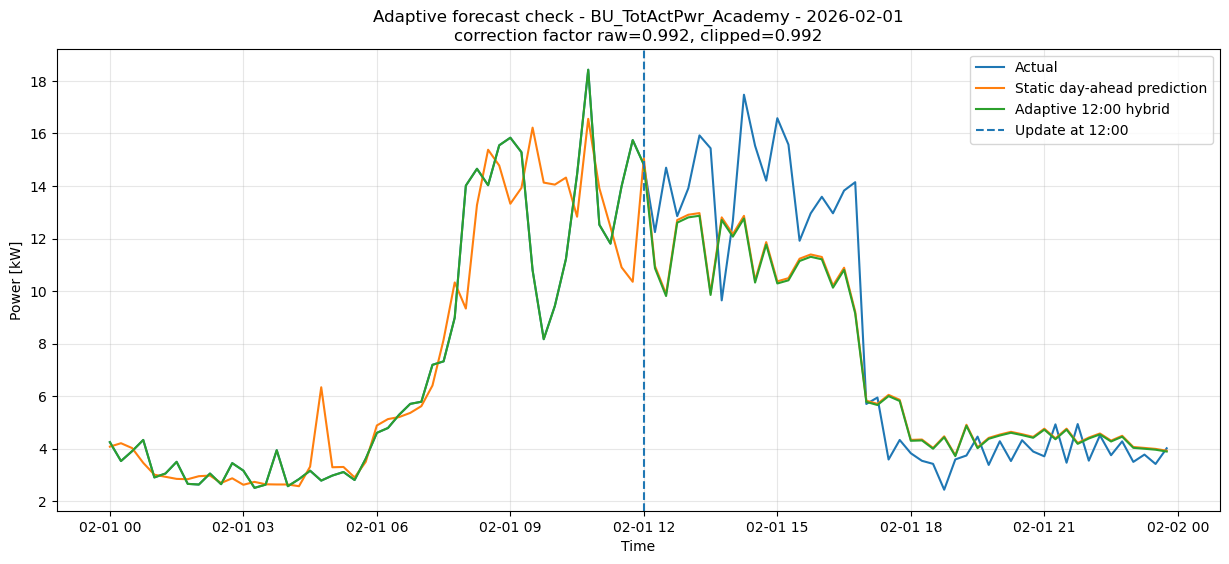

In [15]:
import matplotlib.pyplot as plt

def plot_adaptive_day(df_eval, true_cols, pred_cols, day, update_hour=12):
    day = pd.to_datetime(day).normalize()

    row_df = df_eval[df_eval["forecast_day"] == day]

    if row_df.empty:
        raise ValueError(f"No forecast found for day {day.date()}")

    row = row_df.iloc[0]

    y_true = row[true_cols].to_numpy(dtype=float)
    y_pred = row[pred_cols].to_numpy(dtype=float)

    result = adaptive_scale_profile(
        y_true,
        y_pred,
        update_hour=update_hour,
        freq_minutes=FREQ_MINUTES,
        clip_low=CLIP_LOW,
        clip_high=CLIP_HIGH,
        eps=EPS,
    )

    y_adapt = result["full_day_hybrid_pred"]
    observed_end_step = result["observed_end_step"]

    times = pd.date_range(
        start=day,
        periods=HORIZON_STEPS,
        freq=f"{FREQ_MINUTES}min",
    )

    plt.figure(figsize=(15, 6))
    plt.plot(times, y_true, label="Actual")
    plt.plot(times, y_pred, label="Static day-ahead prediction")
    plt.plot(times, y_adapt, label=f"Adaptive {update_hour:02d}:00 hybrid")

    plt.axvline(
        times[observed_end_step - 1],
        linestyle="--",
        label=f"Update at {update_hour:02d}:00"
    )

    plt.title(
        f"Adaptive forecast check - {TARGET_COL} - {day.date()}\n"
        f"correction factor raw={result['correction_factor_raw']:.3f}, "
        f"clipped={result['correction_factor_clipped']:.3f}"
    )
    plt.ylabel("Power [kW]")
    plt.xlabel("Time")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


plot_adaptive_day(
    df_eval=df_eval,
    true_cols=true_cols,
    pred_cols=pred_cols,
    day="2026-02-01",
    update_hour=12,
)